In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, interpolate, fft
rng=np.random.default_rng()

In [3]:
#theoretical function
N_orig=100
N_samp=10

def input_function(x):
    return np.sin(x)

x_orig=np.linspace(0,4*np.pi,N_orig)
y_orig=input_function(x_orig)

#samples
x_samp=rng.uniform(low=0, high=4*np.pi,size=N_samp)
y_samp=input_function(x_samp)

#sorting x_samp and re-ordering y_samp accordingly
sort_idx = np.argsort(x_samp)
x_samp_sorted = x_samp[sort_idx]
y_samp_sorted = y_samp[sort_idx]

In [4]:
min_x,max_x=min(x_samp_sorted), max(x_samp_sorted)
approx_x=np.linspace(min_x,max_x,N_orig)

#Interpolation (CubicSpline)
interpolation_CS=interpolate.CubicSpline(x_samp_sorted,y_samp_sorted)
approx_y_CS=interpolation_CS(approx_x)

#Interpolation (Barycentric)
interpolation_BC=interpolate.BarycentricInterpolator(x_samp_sorted,y_samp_sorted)
approx_y_BC=interpolation_BC(approx_x)

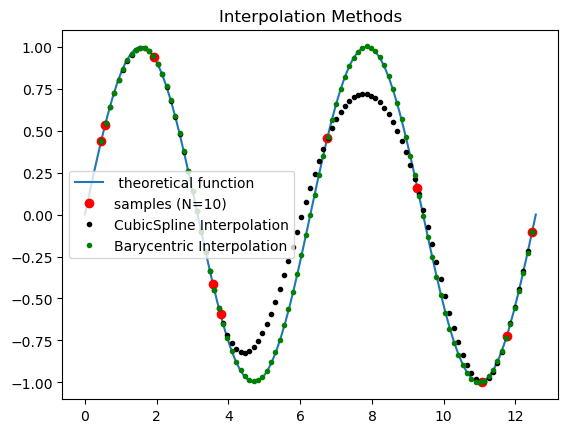

In [5]:
#graphing
fig,ax=plt.subplots()

ax.plot(x_orig,y_orig, label=" theoretical function")
ax.plot(x_samp_sorted,y_samp_sorted, "ro", label="samples (N=10)")
ax.plot(approx_x,approx_y_CS,"k.", label="CubicSpline Interpolation")
ax.plot(approx_x, approx_y_BC, "g.", label="Barycentric Interpolation")
ax.set_title("Interpolation Methods")
ax.legend()


In [6]:
!wget --quiet https://www-personal.umich.edu/~mejn/cp/data/dow.txt

1024


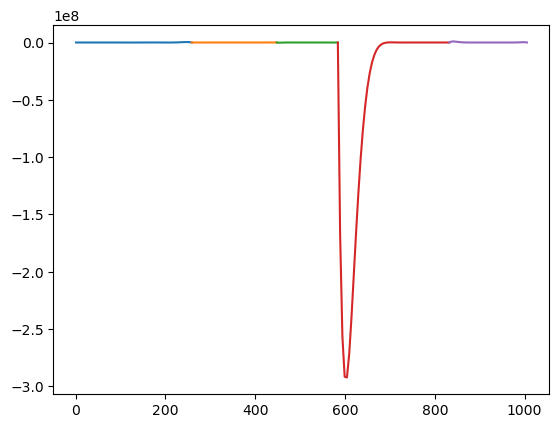

In [16]:
dow_data=np.loadtxt("dow.txt")
print(len(dow_data))
#1024 data points

N_orig=1024

x_samp=rng.choice(range(len(dow_data)),size=int(0.05*N_orig), replace=False) #50% sampling
y_samp=dow_data[x_samp]

#sorting x_samp and re-ordering y_samp accordingly
sort_idx = np.argsort(x_samp)
x_samp_sorted = x_samp[sort_idx]
y_samp_sorted = y_samp[sort_idx]

min_x,max_x=0,1024

approx_x=np.linspace(min_x,max_x,N_orig)

#Interpolation (CubicSpline)
interpolation_CS=interpolate.CubicSpline(x_samp_sorted,y_samp_sorted)
approx_y_CS=interpolation_CS(approx_x)

#Interpolation (Barycentric)
for i in range(int(len(x_samp_sorted)/10)):
    x_seg=x_samp_sorted[10*i:10*i+11]
    y_seg=y_samp_sorted[10*i:10*i+11]

    interpolation_BC=interpolate.BarycentricInterpolator(x_seg,y_seg)
    approx_x_BC=np.linspace(min(x_seg), max(x_seg))
    approx_y_BC=interpolation_BC(approx_x_BC)

    plt.plot(approx_x_BC,approx_y_BC)

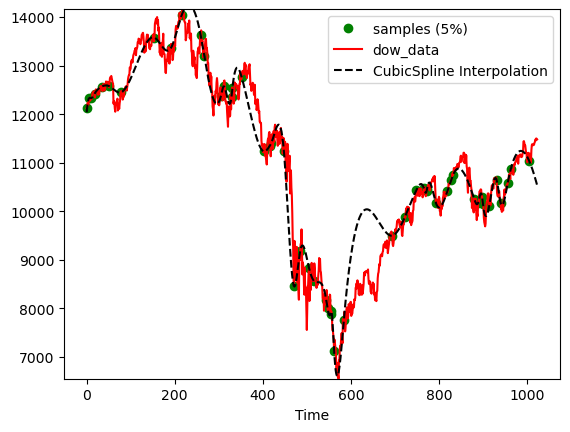

In [17]:
#Graphing
fig,ax=plt.subplots()

ax.plot(x_samp,y_samp, "go", label="samples (5%)")
plt.plot(dow_data, color="red", label="dow_data")
ax.plot(approx_x,approx_y_CS, "k--", label="CubicSpline Interpolation")
#ax.plot(approx_x_BC,approx_y_BC, "b--", label="Barycentric Interpolation")
ax.set_ylim(min(dow_data), max(dow_data))
ax.set_xlabel("Time")
ax.legend()

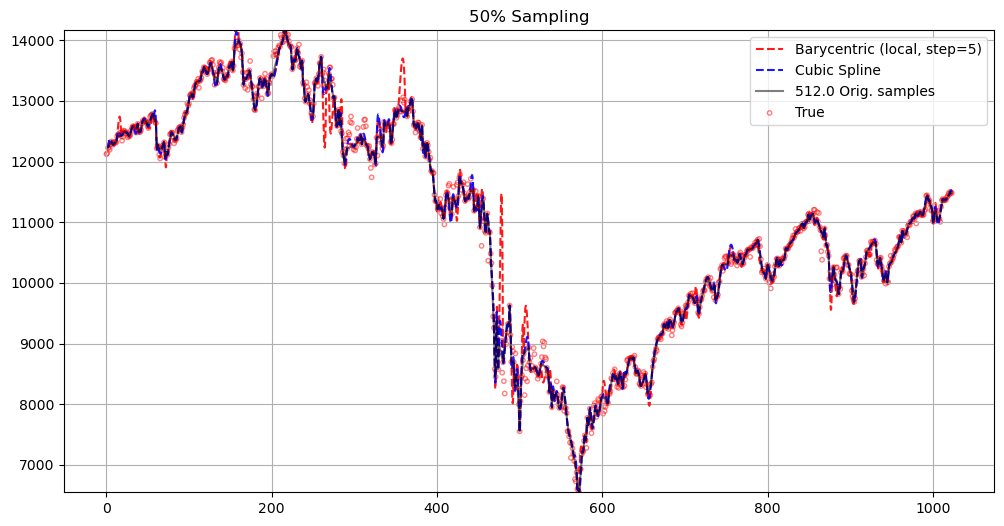

In [21]:
from scipy.interpolate import CubicSpline, BarycentricInterpolator
import numpy as np
import matplotlib.pyplot as plt

# assume rng, dow_data, samp already defined
x = rng.choice(range(len(dow_data)), size=int(N_orig*0.5), replace=False)
y = dow_data[x]

# sort samples
sort_idx2 = np.argsort(x)
x_sort = x[sort_idx2]
y_sort = y[sort_idx2]

# approximation grid
min2 = min(x_sort)
max2 = max(x_sort)
approxx = np.linspace(min2, max2, 10 * int(N_orig* 0.5))

# --- cubic spline ---
interp_cs = CubicSpline(x_sort, y_sort)
approxy = interp_cs(approxx) # cubic spline with original 

# --- barycentric (piecewise with smaller segments) ---
x_all = []
y_all = []

step = 3  # smaller number of points per local polynomial (less oscillation)

for i in range(0, len(x_sort) - step, step):
    x_seg = x_sort[i : i + step + 1]
    y_seg = y_sort[i : i + step + 1]

    interp_bc = BarycentricInterpolator(x_seg, y_seg)

    x_interp = np.linspace(min(x_seg), max(x_seg), 50)
    y_interp = interp_bc(x_interp)

    x_all.append(x_interp)
    y_all.append(y_interp)

x_all = np.concatenate(x_all)
y_all = np.concatenate(y_all)

# Sort for continuous plotting
sort_idx = np.argsort(x_all)
x_all = x_all[sort_idx]
y_all = y_all[sort_idx]

# --- plotting ---
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x_all, y_all, "r--", label="Barycentric (local, step=5)", alpha=0.9)
ax.plot(approxx, approxy, "b--", label="Cubic Spline", alpha=0.9)
ax.plot(x_sort, y_sort, "k-", label=f'{N_orig*0.5} Orig. samples', alpha=0.5)
ax.scatter(range(len(dow_data)), dow_data,
           facecolors='none', edgecolors='red',
           s=10, label="True", alpha=0.5)
ax.set_ylim(min(dow_data), max(dow_data))
ax.set_title('50% Sampling')
ax.grid(True)
ax.legend(loc=1)
plt.show()